# Week 6 - Autoencoder for Image Denoising

Building a deep learning model to reconstruct clean images from noisy versions using autoencoders.

In [20]:
# importing libraries for building and training autoencoder
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Flatten, Reshape
from tensorflow.keras.optimizers import Adam

import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("Imports completed")

Imports completed


In [21]:
# loading mnist dataset from Keras
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

# normalizing to 0-1
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

print("Data is ready")

Training set: (60000, 28, 28)
Test set: (10000, 28, 28)
Data is ready


In [22]:
# creating noisy version of images by adding gaussian noise
noise_factor = 0.3
X_train_noisy = X_train + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=X_train.shape)
X_test_noisy = X_test + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=X_test.shape)

# clipping values to stay between 0 and 1,
X_train_noisy = np.clip(X_train_noisy, 0., 1.)
X_test_noisy = np.clip(X_test_noisy, 0., 1.)

print(f"Noisy data shape: {X_train_noisy.shape}")

Noisy data shape: (60000, 28, 28)


In [23]:
# reshaping images to 784 (28*28) for dense layers
input_size = 784
X_train_flat = X_train.reshape(-1, input_size)
X_test_flat = X_test.reshape(-1, input_size)
X_train_noisy_flat = X_train_noisy.reshape(-1, input_size)
X_test_noisy_flat = X_test_noisy.reshape(-1, input_size)

# building autoencoder..
input_layer = Input(shape=(input_size,))
encoded = Dense(256, activation='relu')(input_layer)
encoded = Dense(128, activation='relu')(encoded)
encoded = Dense(64, activation='relu')(encoded)

decoded = Dense(128, activation='relu')(encoded)
decoded = Dense(256, activation='relu')(decoded)
decoded = Dense(input_size, activation='sigmoid')(decoded)

autoencoder = Model(input_layer, decoded)
autoencoder.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

print(autoencoder.summary())

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 784)            │       201,488 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 484,944 (1.85 MB)

 Trainable params: 484,944 (1.85 MB)

 Non-trainable params: 0 (0.00 B)

None


In [24]:
# training the autoencoder on noisy images to reconstruct the clean images..
history = autoencoder.fit(
    X_train_noisy_flat, X_train_flat,
    epochs=20,
    batch_size=128,
    validation_data=(X_test_noisy_flat, X_test_flat),
    verbose=1
)

print("Training is completed")

Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - loss: 0.0432 - val_loss: 0.0244
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - loss: 0.0218 - val_loss: 0.0196
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - loss: 0.0177 - val_loss: 0.0163
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - loss: 0.0158 - val_loss: 0.0146
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - loss: 0.0144 - val_loss: 0.0137
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - loss: 0.0135 - val_loss: 0.0130
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - loss: 0.0128 - val_loss: 0.0122
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - loss: 0.0122 - val_loss: 0.0118
Epoch 9/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - loss: 0.0117 - val_loss: 0.0116
Epoch 10/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - loss: 0.0113 - val_loss: 0.0112
Epoch 11/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - loss: 0.0110 - val_loss: 0.0110
Epoch 12/20
469/469 ━━━━━━━━━━━━━━━━━━━━

In [25]:
# getting predictions on the test set
decoded_imgs = autoencoder.predict(X_test_noisy_flat)

test_loss = autoencoder.evaluate(X_test_noisy_flat, X_test_flat)
print(f"Test loss: {test_loss:.4f}")

print("Predictions is completed ")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0097
Test loss: 0.0097
Predictions is completed 


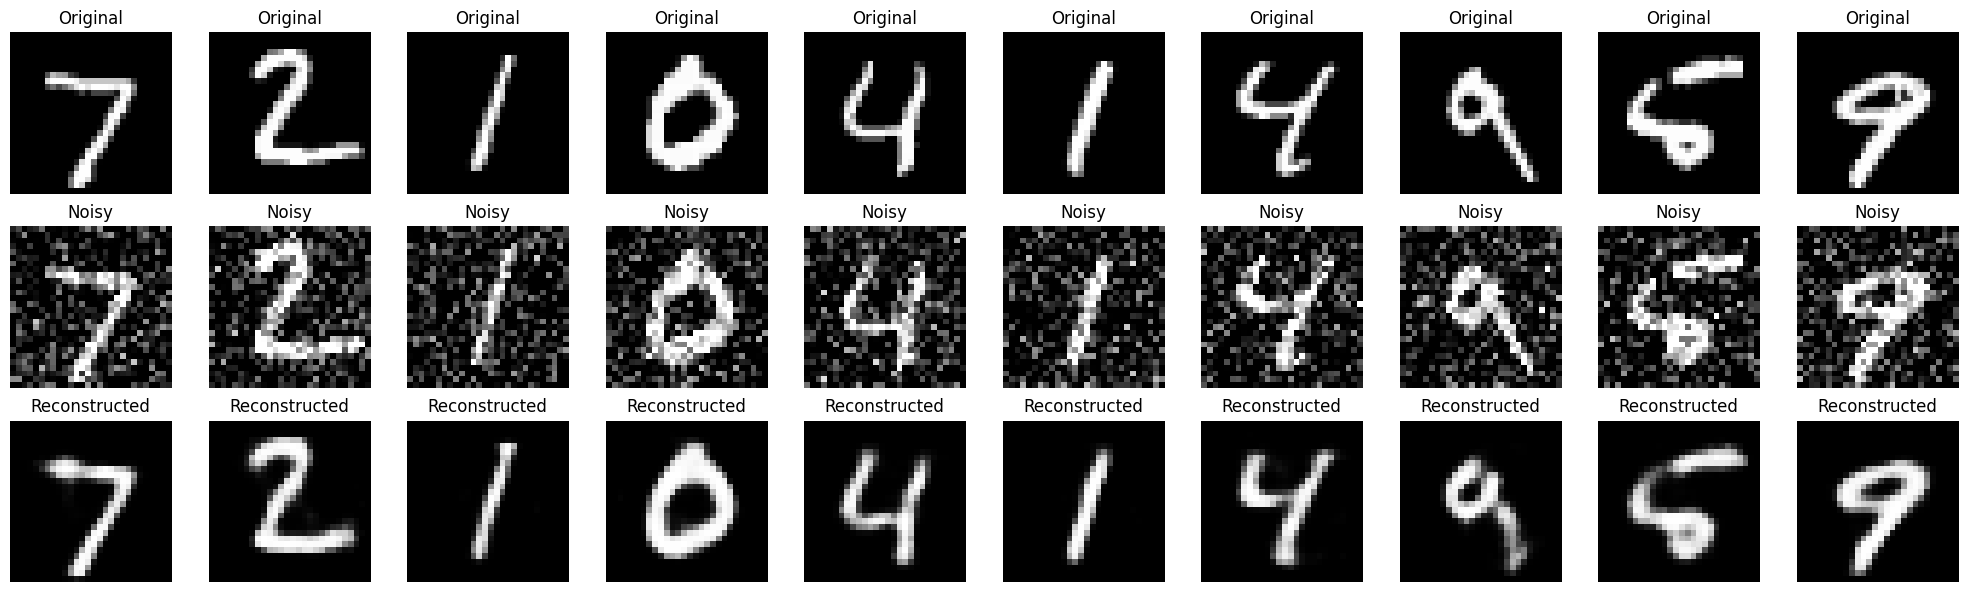

Visualization completed


In [27]:
# visualizing the original, noisy, and reconstructed images
n = 10
plt.figure(figsize=(20, 6))

for i in range(n):
    # original images
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(X_test[i].reshape(28, 28), cmap='gray')
    plt.title('Original')
    plt.axis('off')

    # noisy images
    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(X_test_noisy[i].reshape(28, 28), cmap='gray')
    plt.title('Noisy')
    plt.axis('off')

    # reconstructed images
    ax = plt.subplot(3, n, i + 1 + 2*n)
    plt.imshow(decoded_imgs[i].reshape(28, 28), cmap='gray')
    plt.title('Reconstructed')
    plt.axis('off')

plt.tight_layout()
plt.show()

print("Visualization completed")

In [28]:
# calculating the MSE between original and reconstructed images
mse_reconstructed = np.mean(np.power(X_test_flat - decoded_imgs, 2))
mse_noisy = np.mean(np.power(X_test_flat - X_test_noisy_flat, 2))

print(f"MSE (Noisy vs Original): {mse_noisy:.4f}")
print(f"MSE (Reconstructed vs Original): {mse_reconstructed:.4f}")
print(f"Noise reduction: {((mse_noisy - mse_reconstructed) / mse_noisy * 100):.2f}%")

MSE (Noisy vs Original): 0.0466
MSE (Reconstructed vs Original): 0.0097
Noise reduction: 79.27%


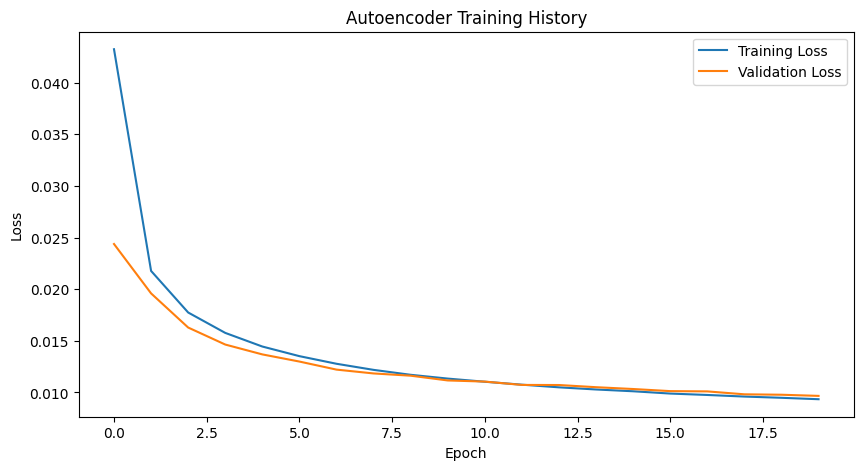

Loss visualization completed


In [29]:
# plotting training loss curve
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Autoencoder Training History')
plt.show()

print("Loss visualization completed")

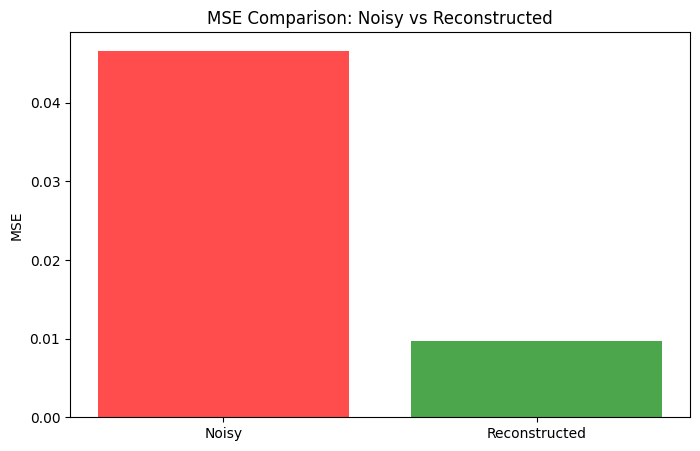

MSE comparison completed


In [30]:
models = ['Noisy', 'Reconstructed']
mse_values = [mse_noisy, mse_reconstructed]
colors = ['red', 'green']

plt.figure(figsize=(8, 5))
plt.bar(models, mse_values, color=colors, alpha=0.7)
plt.ylabel('MSE')
plt.title('MSE Comparison: Noisy vs Reconstructed')
plt.show()

print("MSE comparison completed")

## Key Learnings and Observations..

The autoencoder successfully demonstrated image denoising capabilities on the MNIST dataset.. With a noise reduction of 79.27%, the model effectively compressed noisy input images through an encoder bottleneck and reconstructed clean images in the decoder,, The architecture with layer sizes 784→256→128→64 proved efficient, achieving low MSE on both training and test data

Autoencoders work by learning the underlying structure of data through reconstruction, the encoder learns to extract important features while discarding noise, creating a compressed representation.. The decoder then uses this compact representation to reconstruct the original clean image. This approach is particularly powerful because it requires no labeled data — the model learns purely from input-output pairs where both are the same clean images

In real world applications, autoencoders are used for various tasks beyond denoising. Medical imaging benefits from noise reduction while preserving critical details, anomaly detection leverages autoencoders to identify unusual patterns by measuring reconstruction error. Dimensionality reduction through the bottleneck layer helps visualize high-dimensional data. Data augmentation uses autoencoders to generate new training samples.. The unsupervised nature of autoencoders makes them valuable when labeled data is scarce or expensive to obtain